# Exploration des données — Projet 10 My Content

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

DATA_DIR = "../news-portal-user-interactions-by-globocom"
CLICKS_SAMPLE_PATH = os.path.join(DATA_DIR, "clicks_sample.csv")
CLICKS_DIR = os.path.join(DATA_DIR, "clicks")
ARTICLES_METADATA_PATH = os.path.join(DATA_DIR, "articles_metadata.csv")
ARTICLES_EMBEDDINGS_PATH = os.path.join(DATA_DIR, "articles_embeddings.pickle")

## 1. Aperçu sur `clicks_sample.csv`

In [3]:
clicks_sample = pd.read_csv(CLICKS_SAMPLE_PATH)
print(clicks_sample.shape)
clicks_sample.head()

(1883, 12)


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [4]:
clicks_sample.info()
clicks_sample.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              1883 non-null   int64
 1   session_id           1883 non-null   int64
 2   session_start        1883 non-null   int64
 3   session_size         1883 non-null   int64
 4   click_article_id     1883 non-null   int64
 5   click_timestamp      1883 non-null   int64
 6   click_environment    1883 non-null   int64
 7   click_deviceGroup    1883 non-null   int64
 8   click_os             1883 non-null   int64
 9   click_country        1883 non-null   int64
 10  click_region         1883 non-null   int64
 11  click_referrer_type  1883 non-null   int64
dtypes: int64(12)
memory usage: 176.7 KB


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
count,1883.000000,1.883000e+03,1.883000e+03,1883.000000,1883.000000,1.883000e+03,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000
mean,355.893787,1.506828e+15,1.506828e+12,3.459904,176717.848646,1.506830e+12,3.917153,2.305895,12.113648,1.491768,18.774827,1.764206
std,206.162865,8.679628e+08,8.679468e+05,3.037467,82324.177259,1.064938e+07,0.410461,1.062301,7.825735,2.007772,7.083400,1.225679
min,0.000000,1.506825e+15,1.506825e+12,2.000000,2137.000000,1.506827e+12,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
25%,181.500000,1.506827e+15,1.506827e+12,2.000000,108854.000000,1.506828e+12,4.000000,1.000000,2.000000,1.000000,13.000000,1.000000
50%,353.000000,1.506828e+15,1.506828e+12,3.000000,157541.000000,1.506828e+12,4.000000,3.000000,17.000000,1.000000,21.000000,1.000000
75%,537.000000,1.506828e+15,1.506828e+12,4.000000,236697.500000,1.506829e+12,4.000000,3.000000,19.000000,1.000000,25.000000,2.000000
max,706.000000,1.506829e+15,1.506829e+12,24.000000,363291.000000,1.506998e+12,4.000000,4.000000,20.000000,11.000000,28.000000,7.000000


In [5]:
print("Valeurs manquantes :\n", clicks_sample.isna().sum())
print("\nDoublons :", clicks_sample.duplicated().sum())
print("\nUtilisateurs uniques :", clicks_sample["user_id"].nunique())
print("Articles uniques cliqués :", clicks_sample["click_article_id"].nunique())

Valeurs manquantes :
 user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64

Doublons : 0

Utilisateurs uniques : 707
Articles uniques cliqués : 323


## 2. Assemblage du dossier `clicks/`

In [6]:
def load_all_clicks(clicks_dir: str) -> pd.DataFrame:
    """Concatène tous les fichiers clicks_hour_*.csv en un seul DataFrame."""
    files = sorted(glob.glob(os.path.join(clicks_dir, "clicks_hour_*.csv")))
    print(f"{len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f) for f in files]
    return pd.concat(dfs, ignore_index=True)

clicks = load_all_clicks(CLICKS_DIR)
print(clicks.shape)
clicks.head()

385 fichiers trouvés
(2988181, 12)


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [7]:
# Vérification du schéma et sauvegarde au format parquet (plus compact, plus rapide à recharger)
print(clicks.dtypes)
print("Doublons :", clicks.duplicated().sum())

OUTPUT_PATH = os.path.join(DATA_DIR, "clicks_full.parquet")
clicks.to_parquet(OUTPUT_PATH, index=False)
print(f"Sauvegardé dans {OUTPUT_PATH}")

user_id                object
session_id             object
session_start          object
session_size           object
click_article_id       object
click_timestamp        object
click_environment      object
click_deviceGroup      object
click_os               object
click_country          object
click_region           object
click_referrer_type    object
dtype: object
Doublons : 0
Sauvegardé dans ../news-portal-user-interactions-by-globocom/clicks_full.parquet


## 3. Analyse approfondie du jeu complet de clics

In [15]:
print("Utilisateurs uniques :", clicks["user_id"].nunique())
print("Articles uniques cliqués :", clicks["click_article_id"].nunique())

clicks_per_user = clicks.groupby("user_id").size()
print("\nDistribution du nb de clics par utilisateur :")
print(clicks_per_user.describe())

Utilisateurs uniques : 322897
Articles uniques cliqués : 46033

Distribution du nb de clics par utilisateur :
count    322897.000000
mean          9.254285
std          14.946358
min           2.000000
25%           2.000000
50%           4.000000
75%          10.000000
max        1232.000000
dtype: float64


* 322 897 utilisateurs, 46 033 articles — dataset conséquent
* Moyenne de ~9 clics/user, mais médiane à 4 → distribution très asymétrique (longue queue à droite, max à 1232), indique une grande disparité de comportement entre les users
* 25% des users ont seulement 2 clics — problème de cold-start significatif : beaucoup d'utilisateurs ont très peu d'historique, ce qui va contraindre l'approche CF (Collaborative Filtering)

**Rappel cours**

Le cold-start est le problème qui survient quand un système de recommandation manque d'informations sur un utilisateur ou un article pour faire une recommandation pertinente.

Il existe deux variantes :

*Cold-start utilisateur :* un nouvel utilisateur vient de s'inscrire, il n'a encore rien cliqué. Le système ne sait pas quoi lui recommander car il n'a pas d'historique.

*Cold-start article :* un nouvel article vient d'être publié, personne ne l'a encore cliqué. Le système ne peut pas le recommander via le CF car il n'apparaît dans aucune intéraction.



En Collaborative Filtering, on se base sur les clics passés pour trouver des utilisateurs similaires => un user avec 2 clics donne très peu de signal, et un nouvel article jamais cliqué ne sera jamais recommandé

En Content-Based, on se base sur le contenu (les embeddings) => un nouvel article a quand même un embedding, donc il peut être recommandé dès sa publication. Un nouvel utilisateur peut recevoir des recommandations dès son premier clic.

C'est l'une des grandes forces du content-based dans notre contexte, et un argument clé pour la présentation du projet.



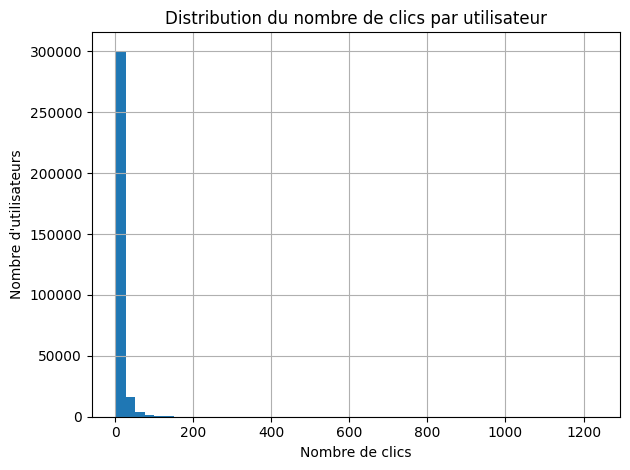

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
clicks_per_user.hist(bins=50, ax=ax)
ax.set_xlabel("Nombre de clics")
ax.set_ylabel("Nombre d'utilisateurs")
ax.set_title("Distribution du nombre de clics par utilisateur")
plt.tight_layout()
plt.show()


* Pour mieux visualiser l'asymétrie (la queue est tellement longue que les petites valeurs sont écrasées), nous allons passer l'axe des x en échelle logarithmique 

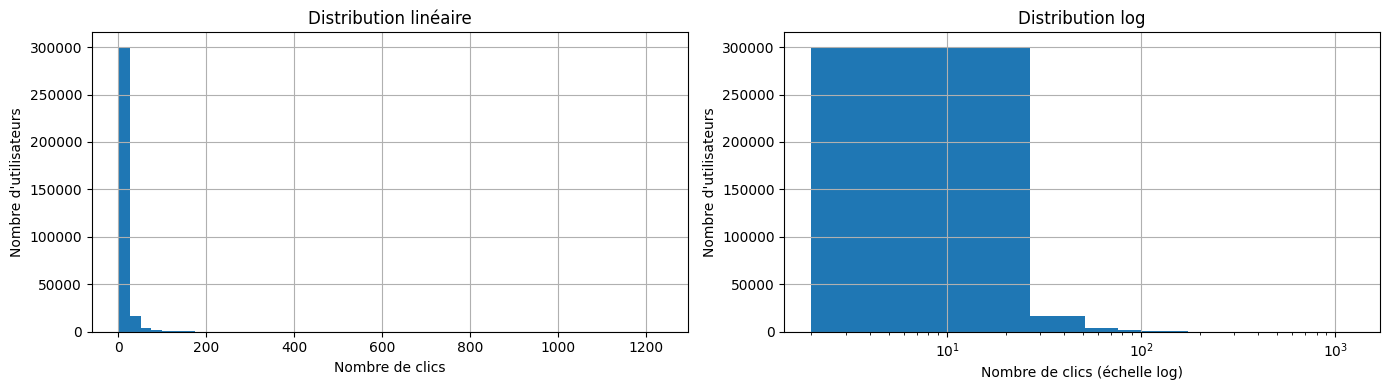

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clicks_per_user.hist(bins=50, ax=axes[0])
axes[0].set_xlabel("Nombre de clics")
axes[0].set_ylabel("Nombre d'utilisateurs")
axes[0].set_title("Distribution linéaire")

clicks_per_user.hist(bins=50, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_xlabel("Nombre de clics (échelle log)")
axes[1].set_ylabel("Nombre d'utilisateurs")
axes[1].set_title("Distribution log")

plt.tight_layout()
plt.show()


* la grande masse des utilisateurs (~300 000) se concentre entre **10⁰ = 1 et 10¹ = 10 clics**, avec un pic visible autour de 2-4 clics. Entre 10¹ et 10² (10 à 100 clics) la barre chute fortement, et au-delà de 10² c'est une queue très fine.

* **Ce que ça signifie concrètement pour le projet :**
La majorité des utilisateurs a très peu d'historique de clics. En Collaborative Filtering, un utilisateur avec 2 ou 3 clics, c'est très peu de signal pour calculer ses similarités avec d'autres users ou pour factoriser la matrice. C'est le **problème du cold-start utilisateur**.

* cela nous indique déjà qu'une approche **content-based** (basée sur le contenu des articles via les embeddings) sera plus robuste pour ces utilisateurs peu actifs.



## 4. Articles & embeddings

In [19]:
articles_metadata = pd.read_csv(ARTICLES_METADATA_PATH)
print(articles_metadata.shape)
articles_metadata.head()

(364047, 5)


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


* Métadonnées articles :

364 047 articles au total, avec 5 colonnes — pas de texte brut, uniquement des métadonnées (catégorie, éditeur, date, nb de mots)

**Remarque importante :** on a 364 047 articles dans les métadonnées, mais seulement 46 033 articles ont été cliqués → la majorité des articles n'a jamais été vue dans le dataset de clics

In [20]:
import pickle

with open(ARTICLES_EMBEDDINGS_PATH, "rb") as f:
    embeddings = pickle.load(f)

print("Shape :", embeddings.shape)
print("Taille en mémoire (Mo) :", embeddings.nbytes / 1e6)

Shape : (364047, 250)
Taille en mémoire (Mo) : 364.047


* Embeddings :

Shape de la matrice (364 047, 250) : chaque article est représenté par un vecteur de 250 dimensions

364 Mo en mémoire (problème évoqué par Julien) : Azure Functions en plan gratuit a une limite mémoire d'environ 1,5 Go, mais le fichier pickle fait déjà 365 Mo sur disque, et une fois chargé en mémoire + traitements, cela devient risqué
C'est pourquoi la **réduction de dimension par PCA** sera nécessaire avant le déploiement sur Azure.

**Rappel cours**

- Un sac de mots (bag-of-words) donnerait un vecteur de taille = vocabulaire (souvent des dizaines de milliers de dimensions), où chaque dimension correspond à un mot précis. C'est une représentation creuse (pleine de zéros).
- Un embedding est une représentation dense et apprise d'un article dans un espace vectoriel de 250 dimensions. Ces 250 dimensions ne correspondent pas à des mots précis — ce sont des concepts latents abstraits, appris par un modèle (par ex un modèle de type Word2Vec ou similaire qui a lu le contenu des articles). l'embedding est une abstraction/représentation du sens du contenu et pas des mots eux-mêmes. C'est la sémantique : le sens du texte est préservé dans l'espace vectoriel.

**Utilité pour la recommandation content-based :**
Si deux articles ont des vecteurs proches (similarité cosinus élevée), ils parlent de sujets similaires. On peut donc recommander à un utilisateur des articles dont les embeddings ressemblent à ceux qu'il a déjà cliqués.

# Conclusion

* Clics : 322 897 users, 46 033 articles cliqués, médiane 4 clics/user
* Articles : 364 047 au total, dont la majorité jamais cliquée
* Embeddings : 364 047 × 250 dims, 365 Mo → PCA nécessaire pour Azure
* Cold-start : Sévère : 25% des users ont ≤ 2 clics :
    - Cold-start article : un nouvel article vient d'être publié, personne ne l'a cliqué => le CF ne peut pas le recommander, mais le content-based si (il a quand même un embedding)
    - Cold-start utilisateur : un nouvel utilisateur vient de s'inscrire, il n'a encore rien cliqué => le CF ne sait pas quoi lui recommander
Dans notre dataset on a vu que le cold-start utilisateur est sévère : 25% des users ont ≤ 2 clics, ce qui est très peu de signal pour le CF.

=> La prochaine étape est la comparaison des modélisations content-based  et collaborative filtering

*Collaborative Filtering* : se base sur les clics des utilisateurs — "des gens similaires à toi ont aimé ces articles"

*Content-Based* : se base sur le contenu des articles via les embeddings — "ces articles ressemblent à ceux que tu as déjà lus"

* Notes pour plus tard:
    - en cas d'ajout d'articles ( énoncé *"l'architecture cible pour prendre en compte l'ajout de nouveaux articles"* ) : 
        - pour l'approche collaborative filtering, il faudra réentrainé avec la nouvelle matrice d'articles, car elle aura changer de dimensions ;
        - pour l'approche content-based : il n'y a pas de réentraînement du modèle de recommandation à proprement parler, mais il faudra quand même calculer les nouveaux embeddings articles et les ajouter à la matrice d'embeddings. Si on a fait une PCA, il faudra aussi projeter ces nouveaux embeddings dans l'espace réduit (avec le pca.transform() déjà entraîné, sans refaire la PCA complète).
    - en cas d'ajout d'utilisateurs :
        - pour le CF : il faut réentrainer car nouveau user = nouveau click. l'ajout d'un nouvel utilisateur pose un problème supplémentaire, même après réentraînement, si le nouvel utilisateur a 0 ou très peu de clics, le modèle ne peut pas calculer ses facteurs correctement. Le CF nécessite un historique minimum pour fonctionner, contrairement au content-based qui démarre dès le premier clic.
        - pour le content-based : si les embeddings ne changent pas (pas de nouveau articles) pas besoin de réentrainé, si les nouveaux users ont zero click, cest le problème du cold start utlisateur. en pratique les systèmes de reco utilisent une recommandation par défaut pour les nouveaux utilisateurs (stratégie du fallback), ou leurs font sélectionner des thèmes de prédilection parmis une liste de thématique 

    